# Direct Regression - Train & Evaluate

- Method: `direct` (ResNet18 backbone + FC(8) head, sigmoid + Wing Loss)
- Data: `data/smartdoc/gt_corners.csv` + `data/midv2020/gt_corners.csv` (combined via csv_path list)
- Scope: small-subset smoke test to verify the Trainer/Evaluator/DirectWrapper pipeline end-to-end.
  Full-dataset training is left to a later session (`scripts/train.py`, not yet implemented).

In [1]:
import os
import sys

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "../.."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

In [2]:
import matplotlib.pyplot as plt

from src.core.factory import get_dataset, get_wrapper
from src.data.dataloader import Dataloader
from src.core.trainer import Trainer, format_result
from src.core.evaluator import Evaluator

## 1. Config

In [3]:
CSV_PATH = [
    os.path.join(PROJECT_ROOT, "data/smartdoc/gt_corners.csv"),
    os.path.join(PROJECT_ROOT, "data/midv2020/gt_corners.csv"),
]
IMAGE_SIZE = 224
BATCH_SIZE = 16
MAX_EPOCHS = 3
NUM_TRAIN_SAMPLES = 500
NUM_VALID_SAMPLES = 100
SEED = 42
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "outputs", "direct_smoke")

## 2. Training

In [4]:
train_dataset = get_dataset("train", CSV_PATH, image_size=IMAGE_SIZE, seed=SEED).subset(NUM_TRAIN_SAMPLES, seed=SEED)
valid_dataset = get_dataset("valid", CSV_PATH, image_size=IMAGE_SIZE, seed=SEED).subset(NUM_VALID_SAMPLES, seed=SEED)
train_loader = Dataloader("train", train_dataset, batch_size=BATCH_SIZE, seed=SEED)
valid_loader = Dataloader("valid", valid_dataset, batch_size=BATCH_SIZE, seed=SEED)

wrapper = get_wrapper("direct", backbone="resnet18")
print("device", wrapper.device)

trainer = Trainer(wrapper, output_dir=OUTPUT_DIR)
history = trainer.fit(train_loader, valid_loader, max_epochs=MAX_EPOCHS)

device cuda
[ 1/3] loss=0.6076 | loss=0.4627
[ 2/3] loss=0.4206 | loss=0.5381
[ 3/3] loss=0.3715 | loss=0.3025


## 3. Evaluation

In [5]:
evaluator = Evaluator(wrapper, output_dir=OUTPUT_DIR)
result = evaluator.evaluate(valid_loader)
print(format_result(result))

iou=0.5635 mcd=0.1001 max_cd=0.1449 reproj_error=0.1001 pck=0.0000 sr=1.0000


## 4. Loss curve

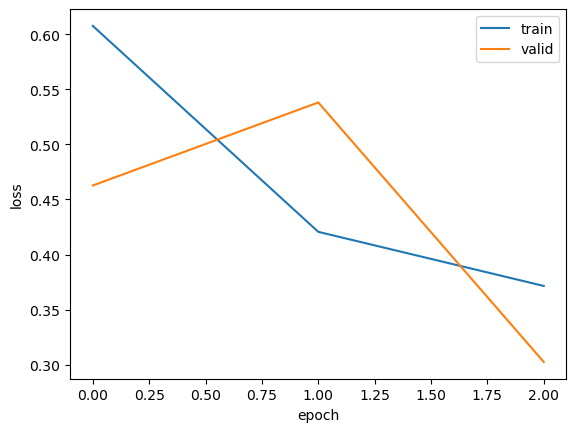

In [6]:
plt.plot(history["train"]["loss"], label="train")
plt.plot(history["valid"]["loss"], label="valid")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()